# Spot Distributions
___

In [11]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_DIR = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / ".git").exists()
)
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "Figure_S10_spot_distributions"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from processing_spot_size import (
    build_audit_dataframe,
    extract_cell_arrays,
    extract_particle_distribution,
    extract_spots_per_cell,
    load_tracking_records,
    plot_cell_means_box_swarm,
    plot_distributions,
    summarize_spots_above_threshold,
)

%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style("ticks")
plt.rcParams.update({
    "font.family": "Arial",
    "axes.linewidth": 2.0,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})


## Configuration

___

In [12]:
INPUT_ROOT = Path("/Volumes/LaCie/UTag_paper_data/ACF")
FIGURES_DIR = NOTEBOOK_DIR / "figures"
RAW_DATA_DIR = NOTEBOOK_DIR / "raw_data"

DATASET_FOLDERS = {
    "utag": "UTag_ACF",
    "utag_c_free": "UTag_CF_ACF",
    "suntag": "SunTag_ACF",
    "alfatag": "AlfaTag_ACF",
}
CONDITION_LABELS = {
    "utag": "UTag",
    "utag_c_free": r"UTag($\Delta$Cys)",
    "suntag": "SunTag",
    "alfatag": "ALFA-tag",
}
CONDITION_EXPORT_LABELS = {
    "utag": "UTag",
    "utag_c_free": "UTag_DeltaCys",
    "suntag": "SunTag",
    "alfatag": "ALFA_tag",
}
CONDITION_COLORS = {
    "utag": "#0173B2",
    "utag_c_free": "#DE8F05",
    "suntag": "#029E73",
    "alfatag": "#CC78BC",
}
CONDITION_KEYS = tuple(DATASET_FOLDERS)

CHANNEL_INDEX = 0
SELECTED_FRAME = None
USE_METADATA_PIXEL_SIZE = False
FIXED_PIXEL_XY_UM = 0.12989318982387477

DISTRIBUTION_MODE = 1  # 1: particle means; 2: all rows; 3: one frame
MIN_SNR_DISTRIBUTIONS = 0.0
SHOW_SIZE_INSET = True
SIZE_INSET_XLIM = (0.5, 1.0)
SIZE_INSET_BOUNDS = (0.43, 0.46, 0.50, 0.34)
SPOT_SIZE_THRESHOLD_UM = 0.5

SPOT_INTENSITY_Y_LIM = (0, 5000)
SNR_Y_LIM = (1, 5)
SPOT_SIZE_Y_LIM = (0.25, 0.6)
LARGE_SPOT_PERCENTAGE_Y_LIM = (-2, 65)
INTENSITY_DISTRIBUTION_X_LIM = (-10, 8000)
SPOT_SIZE_DISTRIBUTION_X_LIM = (0.18, 0.95)

FIGSIZE_BOX = (6.5, 4.5)
FIGSIZE_DENSITY = (6.6, 5.1)
TICK_SIZE = 18
SHOW_STATS = True
SAVE_FORMATS = ("png", "svg")
SAVE_DPI = 600

PLOT_STEMS = {
    "spot_intensity": "S10_X_Intensity_au",
    "snr": "S10_X_SNR",
    "spot_size": "S10_X_Spot_size_um",
    "intensity_distribution": "S10_X_Spot_Intensity_au_probability_density",
    "size_distribution": "Figure_S10B_Spot_Size_um_probability_density",
    "threshold": "Figure_S10C_Spots_above_0p50_um_percent_per_cell",
    "spots_per_cell": "Figure_S10A_Number_of_spots_per_cell",
}

CELL_PLOT_OPTIONS = {
    "condition_labels": [CONDITION_LABELS[key] for key in CONDITION_KEYS],
    "output_dir": FIGURES_DIR,
    "show_stats": SHOW_STATS,
    "figsize": FIGSIZE_BOX,
    "tick_size": TICK_SIZE,
    "save_formats": SAVE_FORMATS,
    "save_dpi": SAVE_DPI,
}
DISTRIBUTION_PLOT_OPTIONS = {
    "condition_labels": CONDITION_LABELS,
    "condition_colors": CONDITION_COLORS,
    "output_dir": FIGURES_DIR,
    "mode": DISTRIBUTION_MODE,
    "figsize": FIGSIZE_DENSITY,
    "inset_bounds": SIZE_INSET_BOUNDS,
    "save_formats": SAVE_FORMATS,
    "save_dpi": SAVE_DPI,
}

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
DISPLAY_TO_EXPORT_LABEL = {
    CONDITION_LABELS[key]: CONDITION_EXPORT_LABELS[key]
    for key in CONDITION_KEYS
}
PAIRWISE_STATISTICS_TABLES = []

def export_cell_plot_source(plot_df, value_column, filename):
    source_df = (
        plot_df.assign(
            condition=plot_df["Condition"].map(DISPLAY_TO_EXPORT_LABEL)
        )
        .rename(columns={"Mean": value_column})
        [["condition", value_column]]
    )
    if source_df["condition"].isna().any():
        raise ValueError(f"Unmapped condition label while exporting {filename}.")
    output_path = RAW_DATA_DIR / filename
    source_df.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")
    return source_df

def export_distribution_source(
        observation_df, curve_df, observation_column, x_column,
        density_column, file_stem):
    observation_source_df = (
        observation_df.assign(
            condition=observation_df["condition_key"].map(
                CONDITION_EXPORT_LABELS
            )
        )
        .rename(columns={"value": observation_column})
        [["condition", observation_column]]
    )
    curve_source_df = (
        curve_df.assign(
            condition=curve_df["condition_key"].map(CONDITION_EXPORT_LABELS)
        )
        .rename(columns={
            "x_value": x_column,
            "probability_density": density_column,
            "n_observations": "n_particle_means",
        })
        [["condition", x_column, density_column, "n_particle_means"]]
    )
    if (
            observation_source_df["condition"].isna().any()
            or curve_source_df["condition"].isna().any()):
        raise ValueError(f"Unmapped condition while exporting {file_stem}.")
    observation_path = RAW_DATA_DIR / f"{file_stem}_particle_means.csv"
    curve_path = RAW_DATA_DIR / f"{file_stem}_KDE_curves.csv"
    observation_source_df.to_csv(observation_path, index=False)
    curve_source_df.to_csv(curve_path, index=False)
    print(f"Saved: {observation_path}")
    print(f"Saved: {curve_path}")
    return observation_source_df, curve_source_df

def collect_pairwise_statistics(pvalue_df, plot_label):
    comparison_parts = pvalue_df["comparison"].str.split(
        " vs ", n=1, expand=True
    )
    statistics_df = pd.DataFrame({
        "plot": plot_label,
        "condition_1": comparison_parts[0].map(DISPLAY_TO_EXPORT_LABEL),
        "condition_2": comparison_parts[1].map(DISPLAY_TO_EXPORT_LABEL),
        "test": "Mann-Whitney U",
        "alternative": "two-sided",
        "p_value": pvalue_df["p_value"].to_numpy(),
        "significance": pvalue_df["significance"].to_numpy(),
    })
    if statistics_df[["condition_1", "condition_2"]].isna().any().any():
        raise ValueError(f"Unmapped condition label in statistics for {plot_label}.")
    statistics_df["annotation_displayed"] = (
        statistics_df["significance"].isin(["*", "**", "***", "****"])
        if SHOW_STATS else False
    )
    PAIRWISE_STATISTICS_TABLES.append(statistics_df)
    return statistics_df

print(f"Input root: {INPUT_ROOT}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Raw-data directory: {RAW_DATA_DIR}")


Input root: /Volumes/LaCie/UTag_paper_data/ACF
Figures directory: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures
Raw-data directory: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/raw_data


## Loading Tracking Data

___

In [13]:
TRACKING_RECORDS = load_tracking_records(
    INPUT_ROOT,
    DATASET_FOLDERS,
    use_metadata_pixel_size=USE_METADATA_PIXEL_SIZE,
    fixed_pixel_xy_um=FIXED_PIXEL_XY_UM,
)
audit_df = build_audit_dataframe(TRACKING_RECORDS, CONDITION_LABELS)
display(audit_df)


,condition,cells/files,dataframe rows,unique particles,pixel sizes (um/px)
0,UTag,19,139658,1257,[0.129893189824]
1,UTag($\Delta$Cys),14,94722,1011,[0.129893189824]
2,SunTag,16,65280,682,[0.129893189824]
3,ALFA-tag,11,76489,652,[0.129893189824]


## Spot Intensity

___

Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/S10_X_Intensity_au.png | /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/S10_X_Intensity_au.svg


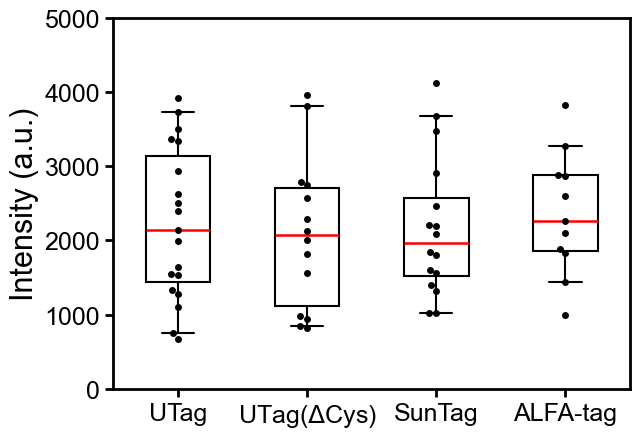

Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/raw_data/S10_X_Intensity_au_cell_means.csv


,Condition,count,mean,std,median
0,UTag,19,2227.160910,1027.091773,2141.971796
1,UTag($\Delta$Cys),14,2090.200908,1027.900608,2067.337403
2,SunTag,16,2170.291675,942.109994,1962.955056
3,ALFA-tag,11,2360.443132,830.589097,2262.753734


,comparison,p_value,significance
0,UTag vs UTag($\Delta$Cys),0.812836,ns
1,UTag vs SunTag,0.907735,ns
2,UTag vs ALFA-tag,0.763220,ns
3,UTag($\Delta$Cys) vs SunTag,0.819150,ns
4,UTag($\Delta$Cys) vs ALFA-tag,0.366372,ns
5,SunTag vs ALFA-tag,0.474286,ns


In [14]:
spot_intensity_data = extract_cell_arrays(
    TRACKING_RECORDS,
    CONDITION_KEYS,
    f"spot_int_ch_{CHANNEL_INDEX}",
    selected_frame=SELECTED_FRAME,
)
spot_intensity_points, spot_intensity_summary, spot_intensity_pvalues = (
    plot_cell_means_box_swarm(
        spot_intensity_data,
        y_label="Intensity (a.u.)",
        plot_stem=PLOT_STEMS["spot_intensity"],
        y_lim=SPOT_INTENSITY_Y_LIM,
        max_percentile_significance=99.0,
        **CELL_PLOT_OPTIONS,
    )
)
spot_intensity_source_data = export_cell_plot_source(
    spot_intensity_points,
    "mean_spot_intensity_au",
    f"{PLOT_STEMS['spot_intensity']}_cell_means.csv",
)
collect_pairwise_statistics(
    spot_intensity_pvalues, PLOT_STEMS["spot_intensity"]
)
display(spot_intensity_summary)
display(spot_intensity_pvalues)


## Signal-to-Noise Ratio

___

Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/S10_X_SNR.png | /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/S10_X_SNR.svg


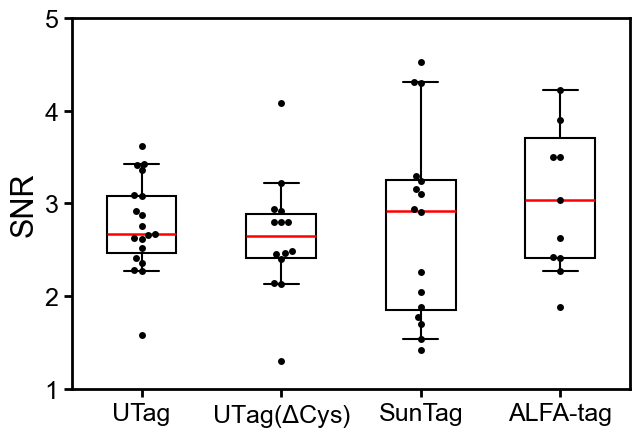

Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/raw_data/S10_X_SNR_cell_means.csv


,Condition,count,mean,std,median
0,UTag,19,2.764830,0.498636,2.667903
1,UTag($\Delta$Cys),14,2.639678,0.627885,2.643690
2,SunTag,16,2.773477,1.021126,2.921948
3,ALFA-tag,11,3.284134,1.259853,3.032708


,comparison,p_value,significance
0,UTag vs UTag($\Delta$Cys),0.477515,ns
1,UTag vs SunTag,0.881546,ns
2,UTag vs ALFA-tag,0.413533,ns
3,UTag($\Delta$Cys) vs SunTag,0.692902,ns
4,UTag($\Delta$Cys) vs ALFA-tag,0.261748,ns
5,SunTag vs ALFA-tag,0.288714,ns


In [15]:
snr_data = extract_cell_arrays(
    TRACKING_RECORDS,
    CONDITION_KEYS,
    f"snr_ch_{CHANNEL_INDEX}",
    selected_frame=SELECTED_FRAME,
)
snr_points, snr_summary, snr_pvalues = plot_cell_means_box_swarm(
    snr_data,
    y_label="SNR",
    plot_stem=PLOT_STEMS["snr"],
    y_lim=SNR_Y_LIM,
    max_percentile_significance=99.0,
    **CELL_PLOT_OPTIONS,
)
snr_source_data = export_cell_plot_source(
    snr_points,
    "mean_spot_snr",
    f"{PLOT_STEMS['snr']}_cell_means.csv",
)
collect_pairwise_statistics(snr_pvalues, PLOT_STEMS["snr"])
display(snr_summary)
display(snr_pvalues)


## Spot Size

___

Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/S10_X_Spot_size_um.png | /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/S10_X_Spot_size_um.svg


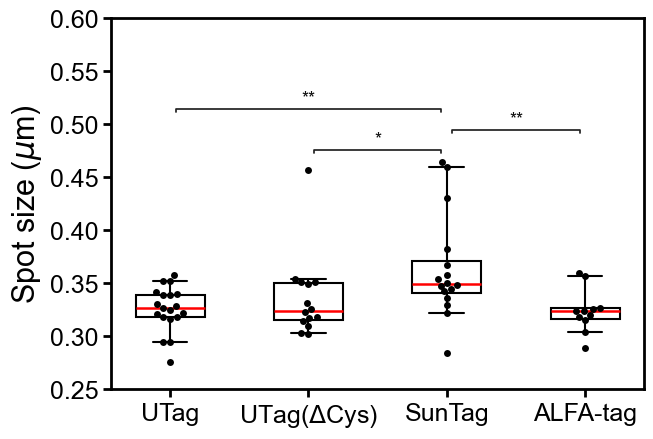

Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/raw_data/S10_X_Spot_size_um_cell_means.csv


,Condition,count,mean,std,median
0,UTag,19,0.325457,0.020996,0.325903
1,UTag($\Delta$Cys),14,0.335850,0.039169,0.323849
2,SunTag,16,0.363407,0.048875,0.348971
3,ALFA-tag,11,0.323579,0.020380,0.323529


,comparison,p_value,significance
0,UTag vs UTag($\Delta$Cys),0.927441,ns
1,UTag vs SunTag,0.002729,**
2,UTag vs ALFA-tag,0.575838,ns
3,UTag($\Delta$Cys) vs SunTag,0.039615,*
4,UTag($\Delta$Cys) vs ALFA-tag,0.848050,ns
5,SunTag vs ALFA-tag,0.008290,**


In [16]:
spot_size_data_um = extract_cell_arrays(
    TRACKING_RECORDS,
    CONDITION_KEYS,
    f"spot_size_ch_{CHANNEL_INDEX}",
    selected_frame=SELECTED_FRAME,
    convert_pixels_to_um=True,
)
spot_size_points, spot_size_summary, spot_size_pvalues = plot_cell_means_box_swarm(
    spot_size_data_um,
    y_label=r"Spot size ($\mu$m)",
    plot_stem=PLOT_STEMS["spot_size"],
    y_lim=SPOT_SIZE_Y_LIM,
    max_percentile_significance=99.9,
    **CELL_PLOT_OPTIONS,
)
spot_size_source_data = export_cell_plot_source(
    spot_size_points,
    "mean_spot_size_um",
    f"{PLOT_STEMS['spot_size']}_cell_means.csv",
)
collect_pairwise_statistics(
    spot_size_pvalues, PLOT_STEMS["spot_size"]
)
display(spot_size_summary)
display(spot_size_pvalues)


## Spot-Intensity Distribution

___

Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/S10_X_Spot_Intensity_au_probability_density.png | /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/S10_X_Spot_Intensity_au_probability_density.svg


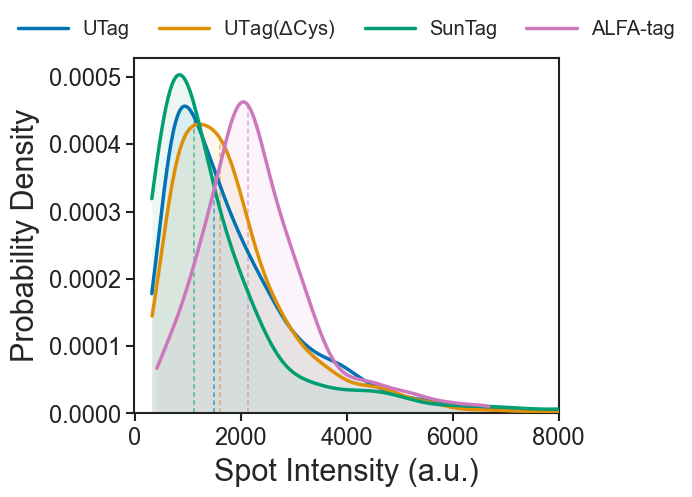

Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/raw_data/S10_X_Spot_Intensity_au_probability_density_particle_means.csv
Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/raw_data/S10_X_Spot_Intensity_au_probability_density_KDE_curves.csv


In [17]:
intensity_distributions = extract_particle_distribution(
    TRACKING_RECORDS,
    CONDITION_KEYS,
    selected_field_prefix="spot_int_ch_",
    channel_index=CHANNEL_INDEX,
    min_snr=MIN_SNR_DISTRIBUTIONS,
)
intensity_distribution_observations, intensity_distribution_curves = (
    plot_distributions(
        intensity_distributions,
        x_label="Spot Intensity (a.u.)",
        plot_stem=PLOT_STEMS["intensity_distribution"],
        xlim=INTENSITY_DISTRIBUTION_X_LIM,
        **DISTRIBUTION_PLOT_OPTIONS,
    )
)
(
    intensity_distribution_source_data,
    intensity_distribution_curve_source_data,
) = export_distribution_source(
    intensity_distribution_observations,
    intensity_distribution_curves,
    "mean_particle_spot_intensity_au",
    "spot_intensity_au",
    "probability_density_per_au",
    PLOT_STEMS["intensity_distribution"],
)


## Spot-Size Distribution

___

The inset displays the configured tail region using the same KDE curves as the main axes.

Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/Figure_S10B_Spot_Size_um_probability_density.png | /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/Figure_S10B_Spot_Size_um_probability_density.svg


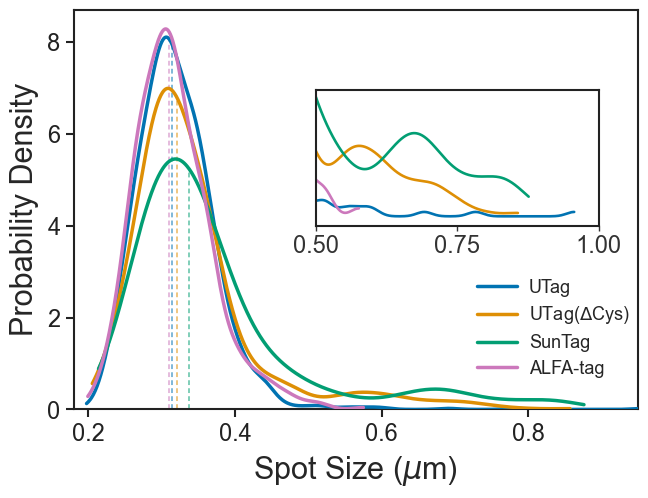

Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/raw_data/Figure_S10B_Spot_Size_um_probability_density_particle_means.csv
Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/raw_data/Figure_S10B_Spot_Size_um_probability_density_KDE_curves.csv


In [18]:
size_distributions = extract_particle_distribution(
    TRACKING_RECORDS,
    CONDITION_KEYS,
    selected_field_prefix="spot_size_ch_",
    channel_index=CHANNEL_INDEX,
    min_snr=MIN_SNR_DISTRIBUTIONS,
    convert_pixels_to_um=True,
)
size_distribution_observations, size_distribution_curves = (
    plot_distributions(
        size_distributions,
        x_label=r"Spot Size ($\mu$m)",
        plot_stem=PLOT_STEMS["size_distribution"],
        xlim=SPOT_SIZE_DISTRIBUTION_X_LIM,
        show_inset=SHOW_SIZE_INSET,
        inset_xlim=SIZE_INSET_XLIM,
        show_density_fill=False,
        legend_inside=True,
        show_tail_background=False,
        show_inset_fill=False,
        show_inset_title=False,
        inset_tick_size=17.0,
        **DISTRIBUTION_PLOT_OPTIONS,
    )
)
(
    size_distribution_source_data,
    size_distribution_curve_source_data,
) = export_distribution_source(
    size_distribution_observations,
    size_distribution_curves,
    "mean_particle_spot_size_um",
    "spot_size_um",
    "probability_density_per_um",
    PLOT_STEMS["size_distribution"],
)


## Spots Above the Size Threshold

___

    Each particle is classified using its mean size across valid frames. Each dot is one cell: $100 \times n_{> threshold}/n_{eligible}$.

Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/raw_data/Figure_S10C_Spots_above_0p50_um_percent_per_cell.csv


,condition,cells,spots_above_threshold,total_valid_spots,mean_cell_percentage,median_cell_percentage,pooled_percentage_above_threshold
0,UTag,19,11,1257,1.181030,0.000000,0.875099
1,UTag($\Delta$Cys),14,67,1011,4.589578,0.000000,6.627102
2,SunTag,16,77,682,8.826583,1.724138,11.290323
3,ALFA-tag,11,4,652,0.442129,0.000000,0.613497


Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/Figure_S10C_Spots_above_0p50_um_percent_per_cell.png | /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/Figure_S10C_Spots_above_0p50_um_percent_per_cell.svg


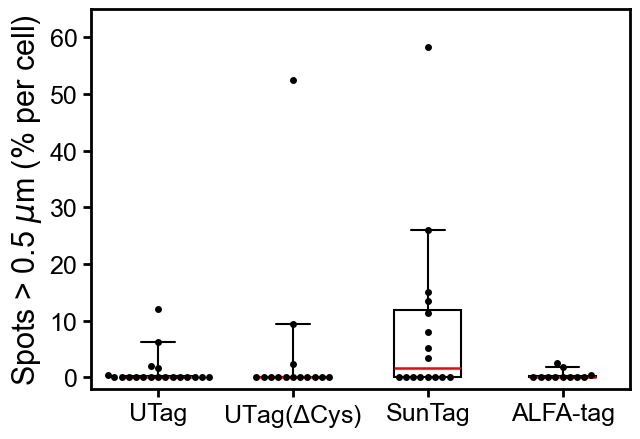

,Condition,count,mean,std,median
0,UTag,19,1.181030,3.016500,0.000000
1,UTag($\Delta$Cys),14,4.589578,14.012142,0.000000
2,SunTag,16,8.826583,15.238454,1.724138
3,ALFA-tag,11,0.442129,0.889852,0.000000


,comparison,p_value,significance
0,UTag vs UTag($\Delta$Cys),0.942078,ns
1,UTag vs SunTag,0.058730,ns
2,UTag vs ALFA-tag,1.000000,ns
3,UTag($\Delta$Cys) vs SunTag,0.106975,ns
4,UTag($\Delta$Cys) vs ALFA-tag,0.970861,ns
5,SunTag vs ALFA-tag,0.080782,ns


In [19]:
large_spot_summary = summarize_spots_above_threshold(
    TRACKING_RECORDS,
    CONDITION_KEYS,
    CONDITION_LABELS,
    threshold_um=SPOT_SIZE_THRESHOLD_UM,
    channel_index=CHANNEL_INDEX,
    min_snr=MIN_SNR_DISTRIBUTIONS,
)
large_spot_source_data = (
    large_spot_summary.assign(
        condition=large_spot_summary["condition_key"].map(
            CONDITION_EXPORT_LABELS
        )
    )
    .rename(columns={
        "spots_above_threshold": "spots_above_0p50_um",
        "percentage_above_threshold": (
            "percentage_spots_above_0p50_um"
        ),
    })
    [[
        "condition",
        "spots_above_0p50_um",
        "total_valid_spots",
        "percentage_spots_above_0p50_um",
    ]]
)
large_spot_source_path = (
    RAW_DATA_DIR / f"{PLOT_STEMS['threshold']}.csv"
)
large_spot_source_data.to_csv(large_spot_source_path, index=False)
print(f"Saved: {large_spot_source_path}")
threshold_token = f"{SPOT_SIZE_THRESHOLD_UM:g}".replace(".", "p")

condition_summary = (
    large_spot_summary.groupby("condition", sort=False)
    .agg(
        cells=("cell_file", "count"),
        spots_above_threshold=("spots_above_threshold", "sum"),
        total_valid_spots=("total_valid_spots", "sum"),
        mean_cell_percentage=("percentage_above_threshold", "mean"),
        median_cell_percentage=("percentage_above_threshold", "median"),
    )
    .reset_index()
)
condition_summary["pooled_percentage_above_threshold"] = np.where(
    condition_summary["total_valid_spots"] > 0,
    100 * condition_summary["spots_above_threshold"]
    / condition_summary["total_valid_spots"],
    np.nan,
)
display(condition_summary)

large_spot_percentage_conditions = []
for key in CONDITION_KEYS:
    values = large_spot_summary.loc[
        large_spot_summary["condition_key"] == key,
        "percentage_above_threshold",
    ].to_numpy(dtype=float)
    large_spot_percentage_conditions.append(
        [np.array([value]) for value in values if np.isfinite(value)]
    )

large_spot_percentage_points, large_spot_percentage_box_summary, large_spot_percentage_pvalues = (
    plot_cell_means_box_swarm(
        large_spot_percentage_conditions,
        y_label=fr"Spots > {SPOT_SIZE_THRESHOLD_UM:g} $\mu$m (% per cell)",
        plot_stem=PLOT_STEMS["threshold"],
        y_lim=LARGE_SPOT_PERCENTAGE_Y_LIM,
        max_percentile_significance=100,
        significance_top_padding=0.12,
        **CELL_PLOT_OPTIONS,
    )
)
collect_pairwise_statistics(
    large_spot_percentage_pvalues, PLOT_STEMS["threshold"]
)
display(large_spot_percentage_box_summary)
display(large_spot_percentage_pvalues)


## Total Spots per Cell

___

Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/Figure_S10A_Number_of_spots_per_cell.png | /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/figures/Figure_S10A_Number_of_spots_per_cell.svg


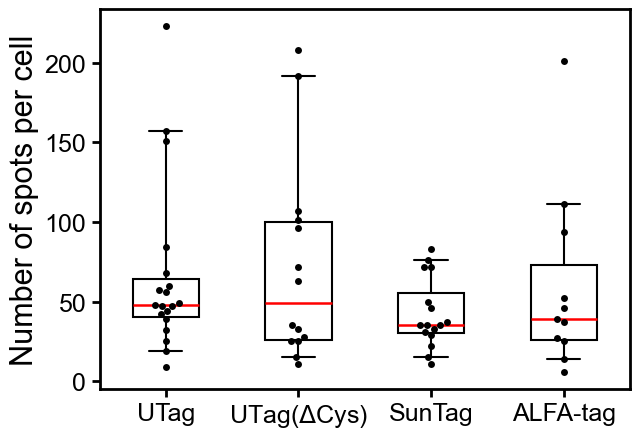

Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/raw_data/Figure_S10A_Number_of_spots_per_cell.csv


,Condition,count,mean,std,median
0,UTag,19,66.157895,53.809606,48.0
1,UTag($\Delta$Cys),14,72.214286,63.143522,49.0
2,SunTag,16,42.625000,22.126530,35.0
3,ALFA-tag,11,59.272727,56.752253,39.0


,comparison,p_value,significance
0,UTag vs UTag($\Delta$Cys),0.956408,ns
1,UTag vs SunTag,0.149575,ns
2,UTag vs ALFA-tag,0.365960,ns
3,UTag($\Delta$Cys) vs SunTag,0.491899,ns
4,UTag($\Delta$Cys) vs ALFA-tag,0.721754,ns
5,SunTag vs ALFA-tag,0.674564,ns


Saved: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_S10_spot_distributions/raw_data/Figure_S10_pairwise_Mann_Whitney_statistics.csv


In [20]:
spots_per_cell_conditions = extract_spots_per_cell(
    TRACKING_RECORDS,
    CONDITION_KEYS,
)
spots_per_cell_points, spots_per_cell_summary, spots_per_cell_pvalues = (
    plot_cell_means_box_swarm(
        spots_per_cell_conditions,
        y_label="Number of spots per cell",
        plot_stem=PLOT_STEMS["spots_per_cell"],
        y_lim=None,
        max_percentile_significance=99.9,
        **CELL_PLOT_OPTIONS,
    )
)
spots_per_cell_source_data = export_cell_plot_source(
    spots_per_cell_points,
    "total_unique_tracked_particles",
    f"{PLOT_STEMS['spots_per_cell']}.csv",
)
collect_pairwise_statistics(
    spots_per_cell_pvalues, PLOT_STEMS["spots_per_cell"]
)
display(spots_per_cell_summary)
display(spots_per_cell_pvalues)

pairwise_statistics_source_data = pd.concat(
    PAIRWISE_STATISTICS_TABLES, ignore_index=True
)
pairwise_statistics_path = (
    RAW_DATA_DIR / "Figure_S10_pairwise_Mann_Whitney_statistics.csv"
)
pairwise_statistics_source_data.to_csv(
    pairwise_statistics_path, index=False
)
print(f"Saved: {pairwise_statistics_path}")
